<section style="font-family: Inter, -apple-system, Roboto, 'Segoe UI', Arial; color:inherit; line-height:1.6; max-width:900px;">

  <h2 style="font-size:1.6rem; margin-bottom:0.3rem;">🎮 Q-Learning ile (Taş–Kağıt–Makas) Oyunu</h2>
  <p style="margin-top:0; opacity:0.9;">
    Bu mini proje, <strong>oyun teorisi</strong> ile <strong>pekiştirmeli öğrenme (reinforcement learning)</strong> arasındaki ilişkiyi küçük ve eğitim amaçlı bir örnekle gösterir. 
    Amaç, rakibin hamlesine karşı en uygun tepkiyi (eylemi) öğrenebilen basit bir ajan tasarlamaktır.
  </p>

  <hr style="border:none; border-top:1px solid rgba(128,128,128,0.25); margin:14px 0;">

  <h3 style="font-size:1.1rem; margin-bottom:0.2rem;">🧩 Problem Özeti</h3>
  <ul style="margin-top:6px; opacity:0.9;">
    <li><strong>Oyun:</strong> 3 hamleli (ör. taş, kağıt, makas benzeri) sıfır-toplamlı oyun.</li>
    <li><strong>Ajan:</strong> Q-learning kullanarak hangi durumda hangi eylemin daha kârlı olduğunu öğrenir.</li>
    <li><strong>Amaç:</strong> Rakibin hamlesine (durum) karşı en iyi tepkiyi (eylem) bulmak.</li>
  </ul>

  <h3 style="font-size:1.1rem; margin-top:10px; margin-bottom:6px;">🔁 Algoritma Özeti</h3>
  <ol style="opacity:0.9;">
    <li>Ajan her <em>durum</em> ve <em>eylem</em> çifti için bir Q-değeri tutar: <code>Q(s,a)</code>.</li>
    <li>Her adımda ajan, mevcut durum için Q-değeri en yüksek eylemi seçer (greedy politika).</li>
    <li>Aldığı ödül ve sonraki durumun Q-değerlerine göre Q tablosunu günceller.</li>
    <li>Zamanla Q-değerleri olgunlaşır ve hangi durumda hangi eylemin daha iyi olduğu ortaya çıkar.</li>
  </ol>

  <div style="background:rgba(128,128,128,0.05); border:1px solid rgba(128,128,128,0.25); padding:10px; border-radius:8px; margin-top:10px;">
    <strong>Güncelleme Denklemi (Bellman tarzı):</strong>
    <div style="margin-top:8px; font-size:1.05rem;">
      $$Q(s,a) = Q(s,a) + \alpha \Big[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Big]$$
    </div>
  </div>

  <h3 style="font-size:1.05rem; margin-top:12px; margin-bottom:6px;">⚙️ Parametreler</h3>
  <table style="border-collapse:collapse; width:100%; max-width:700px; font-size:0.95rem; opacity:0.9;">
    <thead>
      <tr style="border-bottom:1px solid rgba(128,128,128,0.25);">
        <th style="text-align:left; padding:8px 10px;">Parametre</th>
        <th style="text-align:left; padding:8px 10px;">Anlamı</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom:1px solid rgba(128,128,128,0.15);">
        <td style="padding:8px 10px;"><code>learning_rate (α)</code></td>
        <td style="padding:8px 10px;">Güncelleme adımının büyüklüğü — öğrenme hızı.</td>
      </tr>
      <tr style="border-bottom:1px solid rgba(128,128,128,0.15);">
        <td style="padding:8px 10px;"><code>discount_factor (γ)</code></td>
        <td style="padding:8px 10px;">Gelecekteki ödüllerin bugünkü değerini belirler.</td>
      </tr>
      <tr style="border-bottom:1px solid rgba(128,128,128,0.15);">
        <td style="padding:8px 10px;"><code>num_episodes</code></td>
        <td style="padding:8px 10px;">Eğitim için toplam tekrar sayısı.</td>
      </tr>
      <tr>
        <td style="padding:8px 10px;"><code>epsilon (ε)</code></td>
        <td style="padding:8px 10px;">(Opsiyonel) ε-greedy keşif oranı — keşif vs sömürü dengesi için kullanılır.</td>
      </tr>
    </tbody>
  </table>

  <h3 style="font-size:1.05rem; margin-top:12px;">Önemli Notlar</h3>
  <ul style="opacity:0.9;">
    <li><strong>Keşif (exploration):</strong> Tamamen greedy politika (ε=0) başlangıçta kötü sonuçlar verir; ε-greedy keşif eklenmelidir.</li>
    <li><strong>Ortam modellemesi:</strong> Eğer <em>next_state</em> rastgele seçiliyorsa, öğrenilen Q-değerleri o rastgele süreç için geçerlidir. Gerçek rakip stratejileri için self-play gerekir.</li>
    <li><strong>Oyun teorisi perspektifi:</strong> Bu örnek, iki oyunculu sıfır-toplam oyunlarda Q-learning’in nasıl kullanılabileceğini gösterir. Ancak Nash dengesi için min-max tabanlı yöntemler daha uygundur.</li>
  </ul>

  <hr style="border:none; border-top:1px solid rgba(128,128,128,0.25); margin:14px 0;">

   
</section>


In [6]:
import random
import matplotlib.pyplot as plt
import seaborn as sns

 
payoff_matrix = [
    [0, -1,  1],
    [1,  0, -1],
    [-1, 1,  0]
]

 
Q = [[random.random() * 0.1 for _ in range(3)] for _ in range(3)]

alpha = 0.1           
gamma = 0.9           
num_episodes = 1000  
max_steps = 50        
epsilon = 1.0         
epsilon_min = 0.05
epsilon_decay = (epsilon - epsilon_min) / num_episodes

for episode in range(num_episodes):
    state = random.randint(0, 2)
    for _ in range(max_steps):
         
        if random.random() < epsilon:
            action = random.randint(0, 2)
        else:
            action = max(range(3), key=lambda a: Q[state][a])

        next_state = random.randint(0, 2)
        reward = payoff_matrix[state][action]

        
        best_next = max(Q[next_state])
        Q[state][action] += alpha * (reward + gamma * best_next - Q[state][action])

        state = next_state

    epsilon = max(epsilon_min, epsilon - epsilon_decay)

 
print("Final Q-Values:")
for row in Q:
    print([round(v, 3) for v in row])


Final Q-Values:
[9.0, 8.0, 10.0]
[10.0, 9.0, 8.0]
[8.0, 10.0, 9.0]


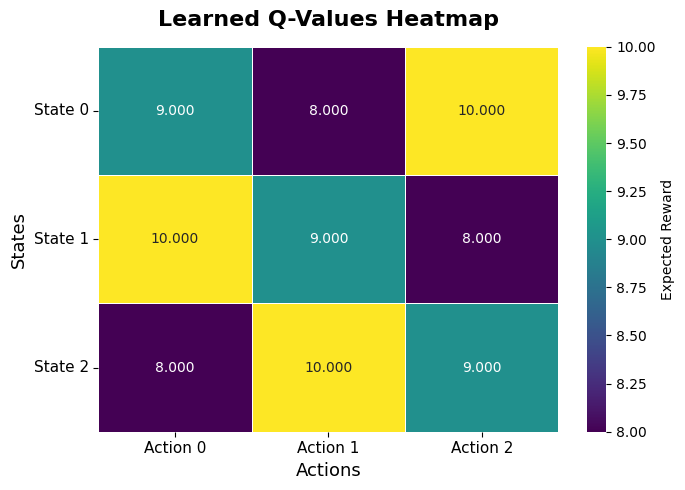

In [7]:
plt.style.use("default")
plt.figure(figsize=(7, 5))
 
sns.heatmap(
    Q,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Expected Reward"},
    xticklabels=["Action 0", "Action 1", "Action 2"],
    yticklabels=["State 0", "State 1", "State 2"]
)

plt.title("Learned Q-Values Heatmap", fontsize=16, weight="bold", pad=15)
plt.xlabel("Actions", fontsize=13)
plt.ylabel("States", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)

plt.tight_layout()
plt.show()
